# Module 4 | Class 3 — Decision Tree vs Random Forest Comparison

**Objective:** Train both a Decision Tree and a Random Forest on the Telco Churn dataset and compare their performance to understand why ensembles tend to outperform single models.

**Dataset:** Telco Customer Churn (Kaggle) — preprocessed the same way as Module 3.

In [1]:
!pip install kagglehub -q

## Task 1: Load and Split Data

We reload and preprocess the Telco Churn dataset the same way as in Module 3 (encoding + scaling), then split into train/test.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import os

path = kagglehub.dataset_download("blastchar/telco-customer-churn")
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

# Same preprocessing as Module 3 / Module 4 Class 2
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

cat_cols = df.select_dtypes(include='object').columns.drop('customerID')
df_encoded = pd.get_dummies(df.drop('customerID', axis=1), columns=cat_cols, drop_first=True)

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

print("X shape:", X.shape)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
X shape: (7043, 30)


/tmp/ipykernel_799/1281122754.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (5634, 30), Test: (1409, 30)


## Task 2: Train a Decision Tree

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Decision Tree F1: {f1_score(y_test, y_pred_dt):.4f}")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7417
Decision Tree F1: 0.5041
              precision    recall  f1-score   support

           0       0.82      0.83      0.83      1035
           1       0.51      0.49      0.50       374

    accuracy                           0.74      1409
   macro avg       0.67      0.66      0.66      1409
weighted avg       0.74      0.74      0.74      1409



## Task 3: Train a Random Forest

In [5]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Random Forest F1: {f1_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7864
Random Forest F1: 0.5501
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.77      0.79      0.78      1409



## Task 4: Visualize the Decision Tree

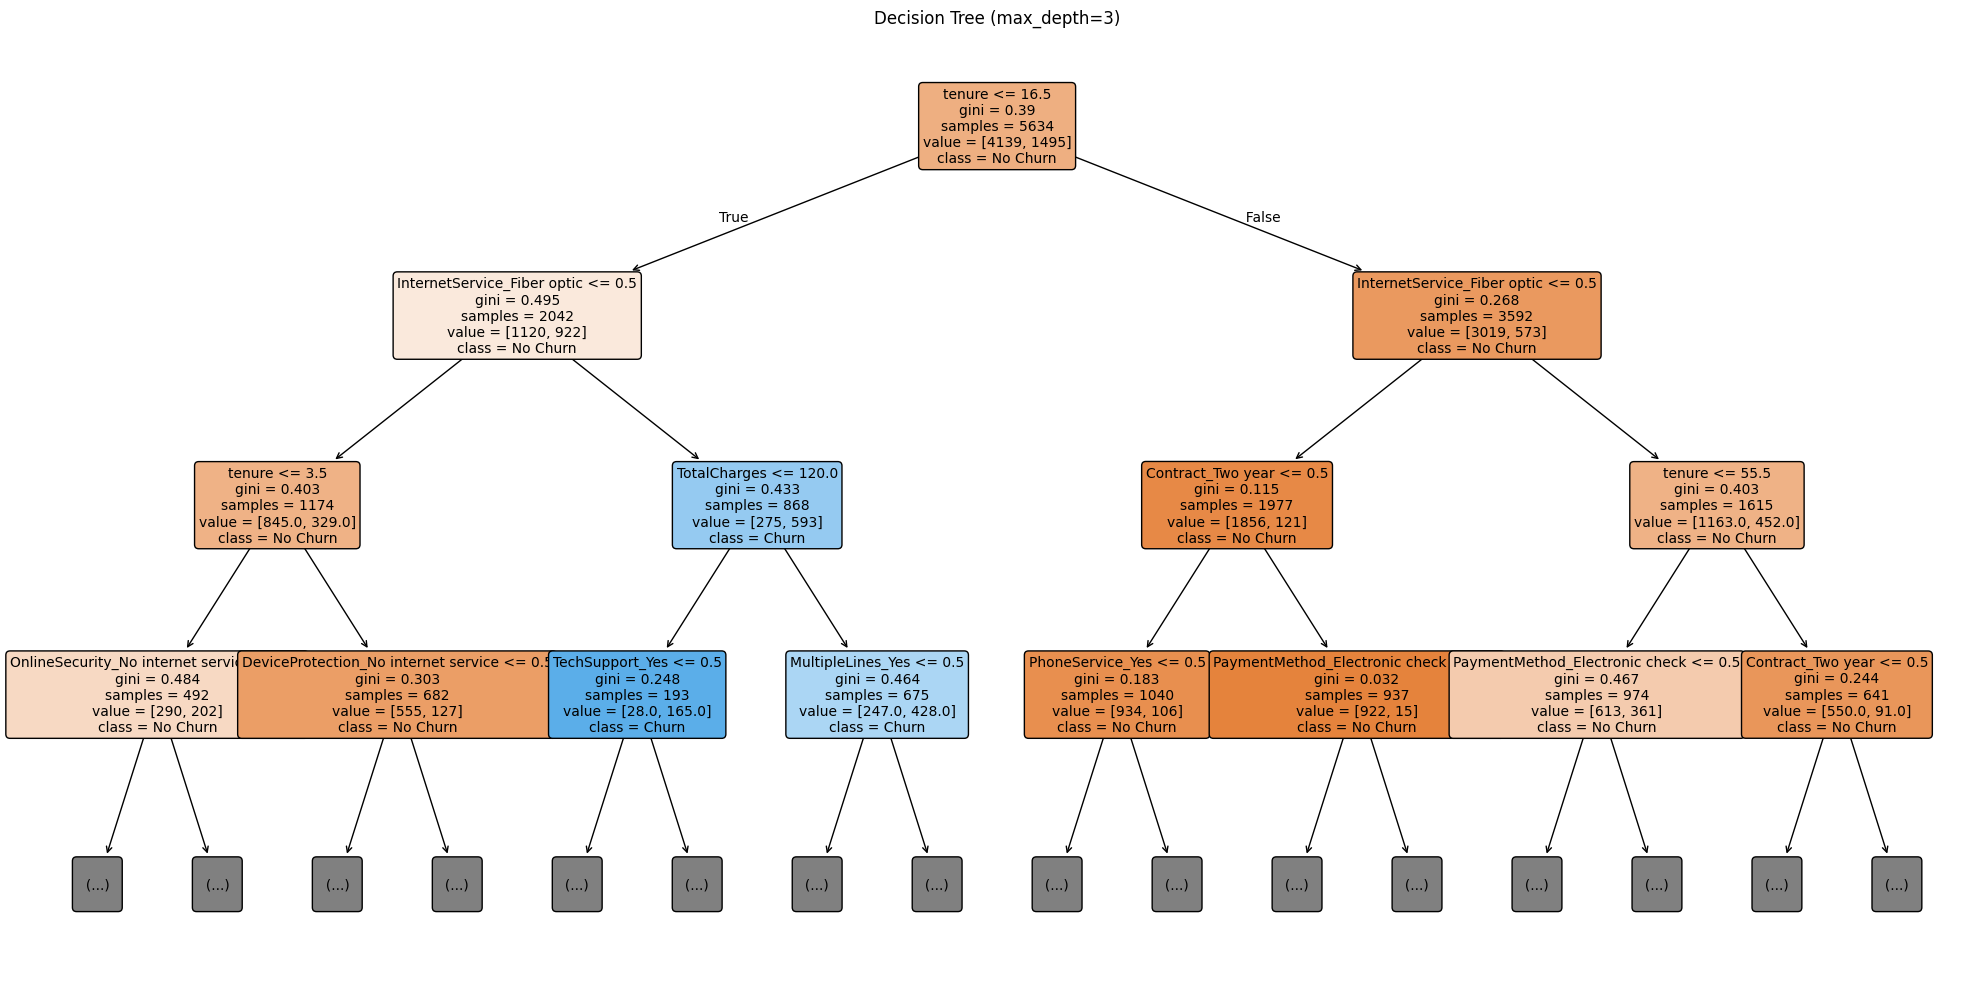

In [6]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(dt, max_depth=3, filled=True, feature_names=X.columns,
          class_names=['No Churn', 'Churn'], fontsize=10, rounded=True)
plt.title('Decision Tree (max_depth=3)')
plt.tight_layout()
plt.show()

**Reading the tree:** each box (node) shows the splitting condition (e.g., `tenure <= -0.5`), the Gini impurity (how mixed the classes are — 0 means perfectly pure), the number of samples that reached that node, and the majority predicted class. Following a path from the top (root) down to a leaf shows one full decision — a specific combination of feature thresholds that leads to a Churn or No Churn prediction.

## Task 5: Extract and Plot Feature Importances

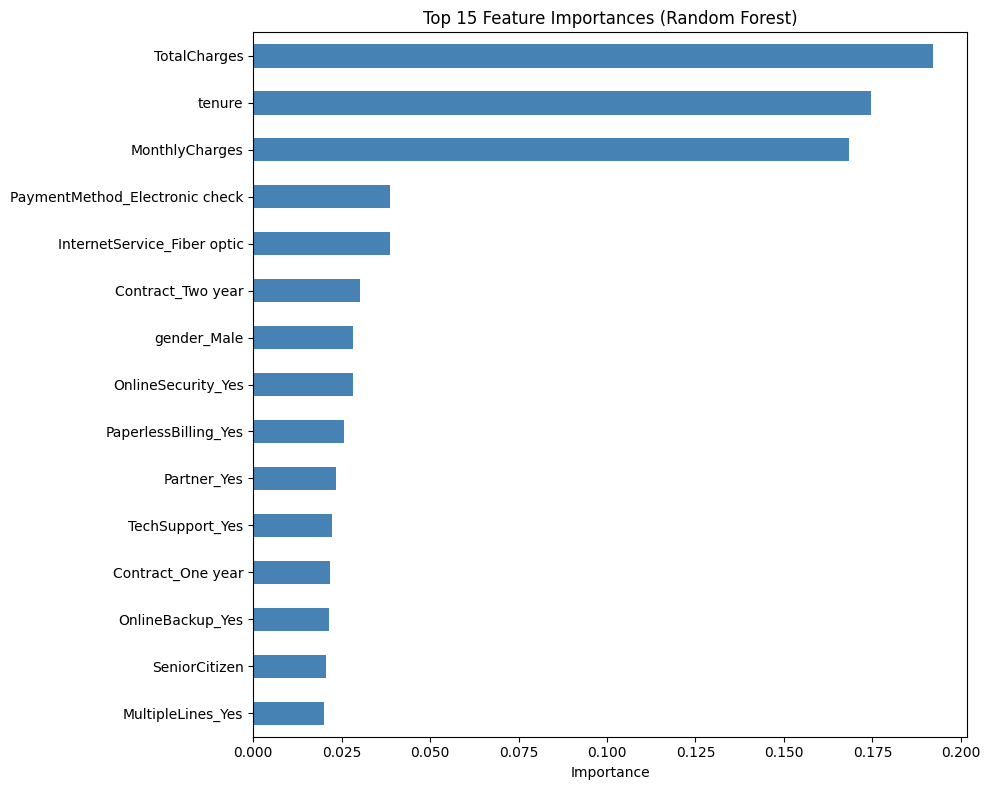

In [7]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_15 = importances.sort_values(ascending=True).tail(15)

top_15.plot(kind='barh', figsize=(10, 8), color='steelblue')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## Task 6: Comparison

In [8]:
summary = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, y_pred_dt), accuracy_score(y_test, y_pred_rf)],
    'F1': [f1_score(y_test, y_pred_dt), f1_score(y_test, y_pred_rf)]
})
summary

,Model,Accuracy,F1
0,Decision Tree,0.741661,0.504087
1,Random Forest,0.786373,0.550075


**Comparison:**

[After running the cells above, fill in your actual Accuracy and F1 numbers from the summary table and complete this paragraph.]

Based on the summary table, the Random Forest achieved [higher/similar] accuracy and F1 compared to the single Decision Tree. This is the expected pattern: a single Decision Tree tends to overfit the training data because it keeps splitting until its leaves are pure (or until it hits a stopping criterion), which makes it very sensitive to the specific quirks of the training set and less able to generalize to new data. A Random Forest addresses this by training many different trees — each on a random subset of the data and a random subset of features — and averaging their predictions. This averaging cancels out the individual trees' overfitting tendencies, producing a more stable, generalizable model.

The tradeoff is interpretability and speed: a single Decision Tree can be visualized and read directly (as in Task 4), making it easy to explain a specific prediction to a non-technical stakeholder. A Random Forest with 100 trees has no single readable structure — we can only summarize it indirectly through feature importances (Task 5), and it takes longer to train and to generate predictions. In practice, Random Forest is usually preferred when predictive performance matters most, while a single Decision Tree may be chosen when explainability of individual decisions is a hard requirement.

*(Replace the bracketed text and adjust the specific claims above to match your actual Accuracy/F1 numbers.)*